# NOTE:
# This notebook is intended to be run on Google Colab.
# It relies on Colab-specific features and preinstalled packages (e.g. yfinance).




In [1]:
############################## Imports ############################
# Core scientific stack
import pandas as pd
import numpy as np

# Market data source (Yahoo Finance)
import yfinance as yf  # Download historical price data

# File system utilities
import os  # Create folders, check paths, list files
from pathlib import Path  # Cleaner path handling than plain strings

# Plotting libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Date and time utilities
from datetime import datetime, timedelta

# Notebook friendliness
%matplotlib inline

In [2]:
######################## Data collection functions ##################

def get_available_crypto_tickers():
    """
    Returns a dictionary of commonly traded cryptocurrencies with their
    corresponding Yahoo Finance tickers.

    Assumptions:
    - We limit ourselves to a fixed universe of large-cap cryptos.
      The user can still manually add other tickers later.
    """
    cryptos = {
        "Bitcoin": "BTC-USD",
        "Ethereum": "ETH-USD",
        "Tether": "USDT-USD",
        "BNB": "BNB-USD",
        "XRP": "XRP-USD",
        "Cardano": "ADA-USD",
        "Dogecoin": "DOGE-USD",
        "Solana": "SOL-USD",
        "Polkadot": "DOT-USD",
        "Litecoin": "LTC-USD",
        "Polygon": "MATIC-USD",
        "Avalanche": "AVAX-USD",
        "Chainlink": "LINK-USD",
        "Uniswap": "UNI-USD",
        "Stellar": "XLM-USD",
    }
    return cryptos


def fetch_yahoo_crypto_data(ticker, period="max", interval="1d"):
    """
    Download OHLCV data for a single cryptocurrency from Yahoo Finance.

    Parameters
    ----------
    ticker : str
        Yahoo Finance ticker (e.g. 'BTC-USD').
    period : str
        How much history to download (e.g. '1y', '5y', 'max').
    interval : str
        Data frequency (e.g. '1d', '1h', '1wk').

    Returns
    -------
    df : pd.DataFrame or None
        DataFrame with columns [date, open, high, low, close, volume]
        or None if the download fails or returns an empty dataset.

    Assumptions:
    - We only keep the standard OHLCV fields.
    - Timezone information is removed to avoid alignment issues later.
    """
    try:
        ticker = str(ticker).strip().upper()
        print(f"Downloading {ticker}...")

        df = yf.Ticker(ticker).history(period=period, interval=interval)

        # If Yahoo returns an empty DataFrame, we skip this ticker
        if df is None or df.empty:
            print(f"✗ No data available for {ticker}")
            return None

        # Reset index so the time index becomes a column
        df = df.reset_index()

        # Standardize column names to lowercase
        df.columns = df.columns.str.lower()

        # yfinance uses "datetime" for intraday intervals; normalize to "date"
        if "date" not in df.columns and "datetime" in df.columns:
            df = df.rename(columns={"datetime": "date"})

        required_cols = ["date", "open", "high", "low", "close", "volume"]
        missing = [c for c in required_cols if c not in df.columns]
        if missing:
            print(f"✗ Missing expected columns for {ticker}: {missing}")
            return None

        # Keep only the relevant columns
        df = df[required_cols].copy()

        # Ensure datetime dtype and remove timezone if present
        df["date"] = pd.to_datetime(df["date"], errors="coerce")
        df = df.dropna(subset=["date"])
        if getattr(df["date"].dt, "tz", None) is not None:
            df["date"] = df["date"].dt.tz_localize(None)

        print(f"✓ Downloaded {ticker}: {len(df)} rows")
        return df

    except Exception as e:
        # Any error (network, ticker not found, etc.) is caught here
        print(f"✗ Error with {ticker}: {e}")
        return None


def collect_crypto_data():
    """
    Non-interactive function to download a fixed CORE7 crypto universe from Yahoo Finance.

    Fixed settings:
    - Universe: core7 = BTC, ETH, BNB, SOL, XRP, LTC, LINK
    - Frequency: daily (interval='1d')
    - Period: 5y

    Notes:
    - No trimming/alignment here: each asset is saved with the full history returned by Yahoo,
      limited only by the chosen period.
    - Output path is relative for portability across Jupyter and Colab.
    """
    print("=" * 70)
    print("YAHOO FINANCE DATA COLLECTION (CORE7, DAILY, 5Y)")
    print("=" * 70)

    # Fixed configuration
    core7 = ["BTC-USD", "ETH-USD", "BNB-USD", "SOL-USD", "XRP-USD", "LTC-USD", "LINK-USD"]
    interval = "1d"
    freq_name = "daily"
    period = "5y"

    print("\nSelected tickers:")
    print(core7)

    # Create output folder (portable path)
    base_path = Path("data") / "YahooFinance"
    out_path = base_path / freq_name
    out_path.mkdir(parents=True, exist_ok=True)

    # Download loop
    success, fail = [], []
    for t in core7:
        df = fetch_yahoo_crypto_data(t, period=period, interval=interval)
        if df is not None and not df.empty:
            csv_path = out_path / f"{t}.csv"
            df.to_csv(csv_path, index=False)
            success.append(t)
            print(f"Saved {t} to {csv_path}")
        else:
            fail.append(t)

    # Save selected tickers
    selected_path = out_path / "selected_tickers.txt"
    with open(selected_path, "w", encoding="utf-8") as f:
        for t in success:
            f.write(t + "\n")

    print("\nDownload complete!")
    print("Successful:", success)
    print("Failed:", fail)
    print(f"Saved selected tickers to {selected_path}")

    return "YahooFinance", freq_name


In [3]:
######################## Database creation ##################

def create_combined_database(exchange="YahooFinance", freq="daily"):
    """
    Create combined datasets (close, open, high, low, volume) from individual CSVs.

    IMPORTANT:
    - Uses ONLY the tickers listed in selected_tickers.txt
      (created during collect_crypto_data).
    - This guarantees that the database and the strategy use
      EXACTLY the same assets selected by the user.

    Jupyter/Colab note:
    - Uses relative paths by default: ./data/<exchange>/<freq>/
    """
    # Input folder containing per-ticker CSVs
    in_dir = Path("data") / exchange / freq

    if not in_dir.exists():
        print(f"Path not found: {in_dir}")
        print("Run data collection (collect_crypto_data) first.")
        return None, None

    # ---------------- READ SELECTED TICKERS ----------------
    selected_path = in_dir / "selected_tickers.txt"

    if not selected_path.exists():
        print("WARNING: selected_tickers.txt NOT found — using ALL per-ticker CSV files in the folder (not recommended).")
        selected_tickers = None
    else:
        with open(selected_path, "r", encoding="utf-8") as f:
            selected_tickers = [line.strip() for line in f.readlines() if line.strip()]
        print("\nUsing ONLY these selected tickers:")
        print(selected_tickers)

    # ---------------- LIST CSV FILES ----------------
    files = [p for p in in_dir.glob("*.csv") if p.name != "selected_tickers.txt"]

    # Filter based on selected tickers (if available)
    if selected_tickers is not None:
        allowed = set(selected_tickers)
        files = [p for p in files if p.stem in allowed]

    if len(files) == 0:
        print("No CSV files available to build the database.")
        return None, None

    # ---------------- LOAD FILES INTO DATAFRAMES ----------------
    dataframes = {}
    for csv_path in files:
        try:
            df = pd.read_csv(csv_path)

            # Normalize columns for robustness
            df.columns = df.columns.str.lower()

            # Basic sanity check: must have a 'date' column
            if "date" not in df.columns:
                print(f"Skipping {csv_path.name}: no 'date' column found.")
                continue

            # Ensure 'date' is a datetime type
            df["date"] = pd.to_datetime(df["date"], errors="coerce")
            df = df.dropna(subset=["date"])

            ticker_name = csv_path.stem
            dataframes[ticker_name] = df

        except Exception as e:
            print(f"Error reading {csv_path}: {e}")

    if len(dataframes) == 0:
        print("No valid CSV files after reading and checks.")
        return None, None

    # ---------------- DETERMINE COMMON COLUMNS ----------------
    # Common fields among all dataframes (excluding 'date')
    common_cols = set.intersection(*[set(df.columns) for df in dataframes.values()])
    common_cols -= {"date"}

    if not common_cols:
        print("No common OHLCV columns found across files.")
        return None, None

    # ---------------- BUILD ONE FILE PER VARIABLE ----------------
    out_dir = Path("data") / exchange
    out_dir.mkdir(parents=True, exist_ok=True)

    for col in sorted(common_cols):
        combined = pd.DataFrame()

        for name, df in dataframes.items():
            if col not in df.columns:
                # Safety check: skip if column is missing in this df
                print(f"Column '{col}' not found in {name}. Skipping this ticker for this variable.")
                continue

            tmp = df[["date", col]].rename(columns={col: name})

            if combined.empty:
                combined = tmp.copy()
            else:
                # Outer merge keeps all dates from all tickers.
                combined = combined.merge(tmp, on="date", how="outer")

        if combined.empty:
            print(f"No data to combine for column '{col}'. Skipping.")
            continue

        combined["date"] = pd.to_datetime(combined["date"], errors="coerce")
        combined = combined.dropna(subset=["date"]).sort_values("date")

        out_path = out_dir / f"{freq}_{col}.csv"
        combined.to_csv(out_path, index=False)
        print("Saved:", out_path)

    print("\nDatabase creation complete.")
    return exchange, freq


In [4]:
######################## Time Series Analysis ##################

def load_and_analyze_data(exchange="YahooFinance", freq="daily"):
    """
    Load combined price data (e.g. daily_close.csv) and perform
    time series analysis and risk/return diagnostics, including:
    - basic statistics
    - advanced risk metrics (skewness, kurtosis, Sortino, VaR, CVaR)
    - plots (prices, normalized prices, returns distribution,
      cumulative returns, correlation heatmap)

    Notes:
    - Non-interactive by design (fixed defaults).
    - Uses portable relative paths for Jupyter/Colab compatibility.
    - Prints a console-friendly summary table (ASCII) without using display().
    """
    # --------------------------------------------------------
    # Helper: pretty ASCII table printer (no external deps)
    # --------------------------------------------------------
    def _print_ascii_table(df: pd.DataFrame, title: str | None = None, max_col_width: int = 32):
        """
        Print a DataFrame as a simple ASCII table (Word/console friendly).
        This is intentionally lightweight and avoids display()/HTML rendering.
        """
        if df is None or df.empty:
            print("(empty table)")
            return

        # Convert everything to string with safe formatting
        out = df.copy()

        # Format floats nicely if possible
        for c in out.columns:
            if pd.api.types.is_numeric_dtype(out[c]):
                out[c] = out[c].map(lambda x: "" if pd.isna(x) else f"{x:.4f}")

        out = out.astype(str)

        # Trim and sanitize cell content
        def _clean_cell(s: str) -> str:
            s = s.replace("\n", " ").replace("\r", " ").strip()
            if len(s) > max_col_width:
                s = s[: max_col_width - 1] + "…"
            return s

        out = out.applymap(_clean_cell)

        headers = [str(c) for c in out.columns]
        rows = out.values.tolist()

        # Compute column widths
        widths = []
        for j, h in enumerate(headers):
            max_len = len(h)
            for r in rows:
                max_len = max(max_len, len(r[j]))
            widths.append(max_len)

        def _line(char: str = "-") -> str:
            return "+" + "+".join([char * (w + 2) for w in widths]) + "+"

        def _row(vals) -> str:
            return "|" + "|".join([f" {v:<{w}} " for v, w in zip(vals, widths)]) + "|"

        if title:
            print(title)

        print(_line("-"))
        print(_row(headers))
        print(_line("="))
        for r in rows:
            print(_row(r))
        print(_line("-"))

    # --------------------------------------------------------
    # 0. Build input/output paths (portable)
    # --------------------------------------------------------
    base_dir = Path("data") / exchange
    file_name = base_dir / f"{freq}_close.csv"

    # Check existence of combined close-price file
    if not file_name.exists():
        print(f"File not found: {file_name}. Run database creation first.")
        return None, None

    # --------------------------------------------------------
    # 1. Load data and set index
    # --------------------------------------------------------
    data = pd.read_csv(file_name)
    data.columns = data.columns.str.lower()

    if "date" not in data.columns:
        print(f"Invalid file format: 'date' column not found in {file_name}")
        return None, None

    data["date"] = pd.to_datetime(data["date"], errors="coerce")
    data = data.dropna(subset=["date"])
    data.set_index("date", inplace=True)
    data.sort_index(inplace=True)

    # Drop assets with more than 50% missing values
    threshold = len(data) * 0.5
    data = data.dropna(axis=1, thresh=threshold)

    # Forward-fill and backward-fill remaining NaNs
    data = data.ffill().bfill()

    if data.empty or data.shape[1] == 0:
        print("No usable data after cleaning (empty dataframe or no assets).")
        return None, None

    # --------------------------------------------------------
    # 2. Data summary
    # --------------------------------------------------------
    print("\n===================== DATA SUMMARY =====================")
    print(f"Rows: {len(data)}")
    print(f"Assets: {len(data.columns)}")
    print(f"Date range: {data.index.min().date()} → {data.index.max().date()}")
    print("\nAssets:")
    for col in data.columns:
        print(" -", col)

    stats = data.describe()
    print("\n================= PRICE STATISTICS =================")
    print(stats.to_string())

    # --------------------------------------------------------
    # 3. Compute returns
    # --------------------------------------------------------
    ret = data.pct_change().dropna()

    print("\n================ RETURNS STATISTICS ===============")
    print(ret.describe().to_string())

    if ret.empty:
        print("Returns dataframe is empty after pct_change().")
        return data, ret

    # --------------------------------------------------------
    # 4. Annualization factor
    # --------------------------------------------------------
    if freq == "daily":
        ann = 252          # trading days per year
    elif freq == "hourly":
        ann = 252 * 24     # 24 hours per trading day for crypto
    else:
        ann = 52           # weekly data

    mean_ret_annual = ret.mean() * ann
    vol_annual = ret.std() * np.sqrt(ann)

    # Sharpe ratio (rf = 0)
    vol_nonzero = vol_annual.replace(0, np.nan)
    sharpe = mean_ret_annual / vol_nonzero

    # --------------------------------------------------------
    # 5. Advanced risk metrics
    # --------------------------------------------------------
    skewness = ret.skew()
    kurtosis = ret.kurt()

    downside = ret.clip(upper=0)
    downside_vol = downside.std() * np.sqrt(ann)
    downside_nonzero = downside_vol.replace(0, np.nan)
    sortino = mean_ret_annual / downside_nonzero

    # VaR (95%) for each asset
    var_95 = ret.quantile(0.05)

    # CVaR (Expected Shortfall) at 95% computed per asset robustly
    cvar_95 = pd.Series(index=ret.columns, dtype=float)
    for c in ret.columns:
        v = var_95[c]
        tail = ret[c][ret[c] <= v]
        cvar_95[c] = tail.mean() if not tail.empty else np.nan

    # Maximum drawdown per asset
    cum = (1 + ret).cumprod()
    running_max = cum.cummax()
    drawdown = (cum - running_max) / running_max
    max_dd = drawdown.min()

    # --------------------------------------------------------
    # 6. Print risk metrics summary
    # --------------------------------------------------------
    print("\n================ ADVANCED RISK METRICS =================\n")

    print("Annual Return (%):")
    print((mean_ret_annual * 100).round(2))

    print("\nAnnual Volatility (%):")
    print((vol_annual * 100).round(2))

    print("\nSharpe Ratio:")
    print(sharpe.round(3))

    print("\nSortino Ratio:")
    print(sortino.round(3))

    print("\nSkewness:")
    print(skewness.round(3))

    print("\nKurtosis:")
    print(kurtosis.round(3))

    print("\nMaximum Drawdown (%):")
    print((max_dd * 100).round(2))

    print("\nValue at Risk 95% (%):")
    print((var_95 * 100).round(2))

    print("\nConditional Value at Risk 95% (%):")
    print((cvar_95 * 100).round(2))

    # --------------------------------------------------------
    # 7. Visualization block
    # --------------------------------------------------------
    fig = plt.figure(figsize=(18, 12))
    gs = fig.add_gridspec(3, 2, hspace=0.3, wspace=0.3)

    # 1: Price evolution (raw prices)
    ax1 = fig.add_subplot(gs[0, :])
    for col in data.columns:
        ax1.plot(data.index, data[col], label=col)
    ax1.set_title(f"Crypto Prices ({freq})")
    ax1.set_xlabel("Date")
    ax1.set_ylabel("Price")
    ax1.legend()

    # 2: Normalized prices (base 100 at start date)
    ax2 = fig.add_subplot(gs[1, 0])
    normalized = data / data.iloc[0] * 100
    for col in normalized.columns:
        ax2.plot(normalized.index, normalized[col])
    ax2.set_title("Normalized Prices (Base 100)")
    ax2.set_xlabel("Date")
    ax2.set_ylabel("Index Level")

    # 3: Return distribution (per-asset histogram overlay)
    ax3 = fig.add_subplot(gs[1, 1])
    ret.plot(kind="hist", bins=50, alpha=0.6, ax=ax3)
    ax3.set_title("Returns Distribution")
    ax3.set_xlabel("Return")
    ax3.set_ylabel("Frequency")

    # 4: Cumulative returns per asset
    ax4 = fig.add_subplot(gs[2, 0])
    cum_returns = (1 + ret).cumprod()
    for col in cum_returns.columns:
        ax4.plot(cum_returns.index, cum_returns[col])
    ax4.set_title("Cumulative Returns")
    ax4.set_xlabel("Date")
    ax4.set_ylabel("Growth of 1 unit")

    # 5: Correlation heatmap of returns
    ax5 = fig.add_subplot(gs[2, 1])
    corr = ret.corr()
    sns.heatmap(corr, annot=False, cmap="RdYlGn", center=0, ax=ax5)
    ax5.set_title("Return Correlation")

    plt.show()

    # --------------------------------------------------------
    # 8. Build and save summary table
    # --------------------------------------------------------
    summary = pd.DataFrame({
        "Asset": data.columns,
        "Annual Return %": mean_ret_annual.reindex(data.columns).values * 100,
        "Annual Volatility %": vol_annual.reindex(data.columns).values * 100,
        "Sharpe Ratio": sharpe.reindex(data.columns).values,
        "Sortino Ratio": sortino.reindex(data.columns).values,
        "Skewness": skewness.reindex(data.columns).values,
        "Kurtosis": kurtosis.reindex(data.columns).values,
        "Max Drawdown %": max_dd.reindex(data.columns).values * 100,
        "VaR 95% %": var_95.reindex(data.columns).values * 100,
        "CVaR 95% %": cvar_95.reindex(data.columns).values * 100,
        "Current Price": data.iloc[-1].reindex(data.columns).values,
        "Start Price": data.iloc[0].reindex(data.columns).values,
        "Total Return %": (data.iloc[-1] / data.iloc[0] - 1).reindex(data.columns).values * 100,
    })

    # Sort by Sharpe ratio
    summary = summary.sort_values("Sharpe Ratio", ascending=False)

    # Save CSV
    summary_path = base_dir / f"{freq}_summary_table.csv"
    summary.to_csv(summary_path, index=False)
    print("\nSaved summary table to:", summary_path)

    # Save a Word-friendly TSV (tab-delimited), but do not print it
    word_path = base_dir / f"{freq}_summary_table_word.tsv"
    summary.to_csv(word_path, sep="\t", index=False, float_format="%.4f")
    print("Saved Word-friendly TSV to:", word_path)

    # Print a console-friendly table (ASCII) without display()
    print("\n================ SUMMARY TABLE (CONSOLE) ================\n")
    _print_ascii_table(summary, title=None, max_col_width=32)

    return data, ret


CRYPTOCURRENCY ANALYSIS TOOL — BASIC WORKFLOW (NON-INTERACTIVE)
YAHOO FINANCE DATA COLLECTION (CORE7, DAILY, 5Y)

Selected tickers:
['BTC-USD', 'ETH-USD', 'BNB-USD', 'SOL-USD', 'XRP-USD', 'LTC-USD', 'LINK-USD']
✓ Downloaded BTC-USD: 1827 rows
Saved BTC-USD to data/YahooFinance/daily/BTC-USD.csv
✓ Downloaded ETH-USD: 1827 rows
Saved ETH-USD to data/YahooFinance/daily/ETH-USD.csv
✓ Downloaded BNB-USD: 1827 rows
Saved BNB-USD to data/YahooFinance/daily/BNB-USD.csv
✓ Downloaded SOL-USD: 1827 rows
Saved SOL-USD to data/YahooFinance/daily/SOL-USD.csv
✓ Downloaded XRP-USD: 1827 rows
Saved XRP-USD to data/YahooFinance/daily/XRP-USD.csv
✓ Downloaded LTC-USD: 1827 rows
Saved LTC-USD to data/YahooFinance/daily/LTC-USD.csv
✓ Downloaded LINK-USD: 1827 rows
Saved LINK-USD to data/YahooFinance/daily/LINK-USD.csv

Download complete!
Successful: ['BTC-USD', 'ETH-USD', 'BNB-USD', 'SOL-USD', 'XRP-USD', 'LTC-USD', 'LINK-USD']
Failed: []
Saved selected tickers to data/YahooFinance/daily/selected_tickers.tx

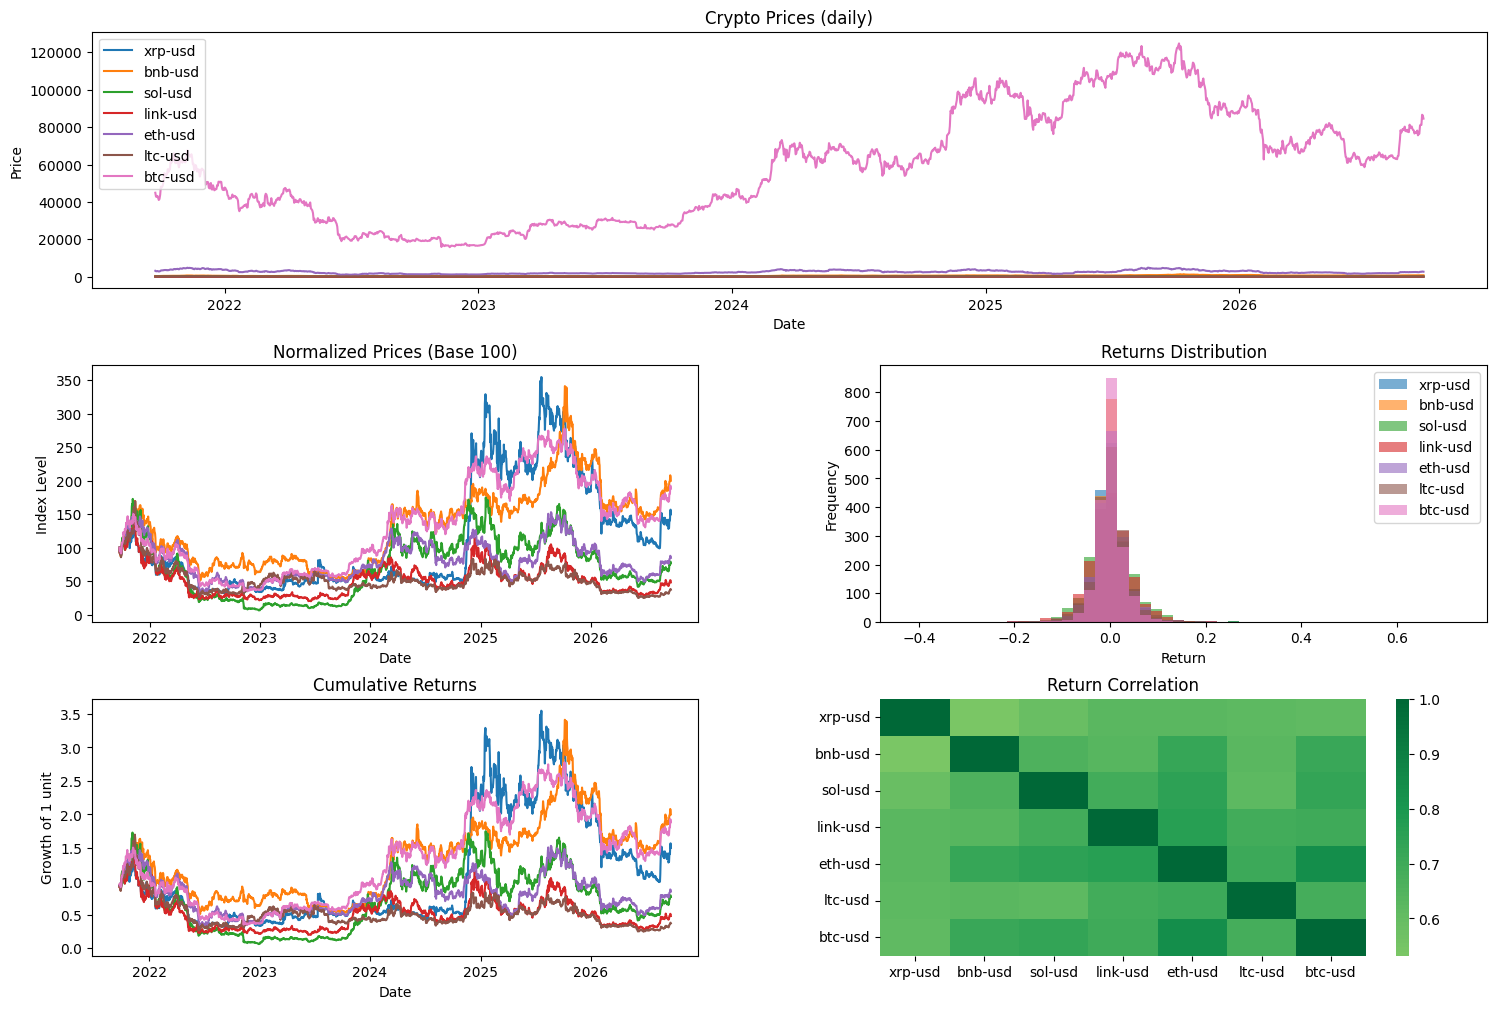


Saved summary table to: data/YahooFinance/daily_summary_table.csv
Saved Word-friendly TSV to: data/YahooFinance/daily_summary_table_word.tsv

================ SUMMARY TABLE (CONSOLE) ================

+----------+-----------------+---------------------+--------------+---------------+----------+----------+----------------+-----------+------------+---------------+-------------+----------------+
| Asset    | Annual Return % | Annual Volatility % | Sharpe Ratio | Sortino Ratio | Skewness | Kurtosis | Max Drawdown % | VaR 95% % | CVaR 95% % | Current Price | Start Price | Total Return % |
+==========+=================+=====================+==============+===============+==========+==========+================+===========+============+===============+=============+================+
| bnb-usd  | 20.9271         | 47.5958             | 0.4397       | 0.7264        | -0.0133  | 4.4611   | -69.8856       | -4.4700   | -6.9708    | 768.1500      | 383.8204    | 100.1327       |
| btc-usd  | 17.90

/tmp/ipykernel_3467/2897356208.py:46: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  out = out.applymap(_clean_cell)


In [5]:
######################## Main Execution (Basic Workflow Only) ##################

"""
This cell runs the three core steps in sequence:
1. Data collection
2. Database creation
3. Time series analysis

All advanced steps (Trend-Following, Markowitz, OOS testing, macro correlations)
should be run manually in separate cells to maintain transparency
and avoid unintended long computations.

Assumptions:
- Non-interactive execution (no menu / no input prompts).
- Fixed configuration is used across the pipeline (CORE7, daily, 5y).
"""

print("=" * 70)
print("CRYPTOCURRENCY ANALYSIS TOOL — BASIC WORKFLOW (NON-INTERACTIVE)")
print("=" * 70)

# Step 1: collect data (fixed CORE7, daily, 5y; saves under ./data/YahooFinance/daily/)
exchange, freq = collect_crypto_data()

# Step 2: create combined OHLCV database for the same exchange/frequency
create_combined_database(exchange=exchange, freq=freq)

# Step 3: run time series analysis on the same exchange/frequency
data, ret = load_and_analyze_data(exchange=exchange, freq=freq)

print("\nPipeline completed.")


In [6]:
######################## Trend-Following Portfolio Models (20/100) ##################
# This cell defines:
#   - compute_trend_signals: MA20 / MA100 trend filter
#   - backtest_trend_equal_weight: long-only TF, equal weights
#   - backtest_trend_max_sharpe: long-only TF, Markowitz max Sharpe
#   - backtest_trend_min_var: long-only TF, Markowitz min variance
#   - backtest_trend_max_diversification: long-only TF, max diversification ratio
#   - backtest_trend_risk_parity: long-only TF, naive risk parity (inverse volatility)
#
# Assumptions:
#   - DAILY data.
#   - Only long positions (no shorts): negative weights are clipped to 0.
#   - Rebalancing happens daily.
#   - Transaction costs proportional to turnover.
#   - Parameters (covariance, mean returns) estimated on a rolling window.
#   - MAX WEIGHT PER ASSET is enforced (e.g. 25%), based on typical
#     portfolio construction practice (10–25% per single name).

def compute_trend_signals(prices, short_window=20, long_window=100):
    """
    Compute trend-following signals based on moving average crossovers.

    For each asset and each date:
      signal = 1 (LONG) if MA_short > MA_long
      signal = 0 (FLAT) otherwise.
    """
    prices = prices.sort_index()
    signals = pd.DataFrame(index=prices.index, columns=prices.columns)

    for asset in prices.columns:
        ma_short = prices[asset].rolling(short_window).mean()
        ma_long = prices[asset].rolling(long_window).mean()
        signals[asset] = (ma_short > ma_long).astype(int)

    return signals


def _apply_max_weight(w_active, max_weight):
    """
    Enforce a maximum weight per asset.

    - Clip each weight at max_weight.
    - Let total = sum of clipped weights.
    - If total >= 1: normalize to sum to 1 (fully invested).
    - If total < 1: keep as is (remaining part stays in cash).
      -> This prevents putting 100% into a single asset when it is
         the only one in trend: e.g., with max_weight=0.25, you
         invest 25% and keep 75% in cash.
    """
    w = w_active.copy()
    w = w.clip(lower=0.0)

    # Cap each asset
    w = w.where(w <= max_weight, max_weight)

    total = w.sum()

    if total == 0:
        return w

    if total >= 1.0:
        # Fully invested, but respecting cap
        return w / total
    else:
        # Not fully invested, some cash left
        return w


def _backtest_trend_generic(
    returns,
    signals,
    model="equal_weight",
    estimation_window=90,
    min_history=30,
    transaction_fee=0.001,
    max_weight=0.25,
    name="TF_Generic"
):
    """
    Generic trend-following backtester with different portfolio construction models.

    Models:
      - 'equal_weight'        : equal weights among all assets in trend
      - 'max_sharpe'          : Markowitz max Sharpe (approx, long-only by clipping)
      - 'min_var'             : Markowitz min variance (approx, long-only by clipping)
      - 'max_diversification' : max diversification ratio (approx, Σ^{-1} * vol)
      - 'risk_parity'         : naive risk parity via inverse volatility

    Parameters
    ----------
    returns : pd.DataFrame
        Daily returns of the assets (index = dates, columns = assets).
    signals : pd.DataFrame
        Binary 0/1 trend signals, same shape as returns.
    model : str
        One of ['equal_weight', 'max_sharpe', 'min_var',
                'max_diversification', 'risk_parity'].
    estimation_window : int
        Lookback window (in days) used to estimate covariance / mean.
    min_history : int
        Minimum number of observations required to use a model.
        If not enough history, fallback to equal weight among active assets.
    transaction_fee : float
        Proportional transaction cost per unit of turnover.
    max_weight : float
        Maximum allowed weight per single asset (e.g. 0.25 = 25%).
    name : str
        Name for the returned net return series.

    Returns
    -------
    net_returns : pd.Series
    weights_df  : pd.DataFrame
    raw_returns : pd.Series
    cost_series : pd.Series
    """

    # Ensure consistent ordering and alignment
    returns = returns.sort_index()
    signals = signals.sort_index()

    # Align on index (dates)
    returns, signals = returns.align(signals, join="inner", axis=0)
    # Align on columns (assets)
    returns, signals = returns.align(signals, join="inner", axis=1)

    dates = returns.index
    assets = returns.columns

    net_list = []
    raw_list = []
    cost_list = []
    weight_history = []

    # Start from zero weights (cash)
    prev_weights = pd.Series(0.0, index=assets)

    for t in range(1, len(dates)):
        yesterday = dates[t - 1]
        today = dates[t]

        # 1) Assets in trend at t-1
        sig = signals.loc[yesterday]
        active_assets = sig[sig == 1].index.tolist()

        if len(active_assets) == 0:
            # No asset in trend → stay in cash
            w = pd.Series(0.0, index=assets)
        else:
            # 2) Extract historical window of returns up to t-1
            hist_mask = (returns.index <= yesterday)
            window_ret = returns.loc[hist_mask].iloc[-estimation_window:]
            window_ret = window_ret[active_assets]

            # If too few observations, fallback to equal weight among active
            if window_ret.shape[0] < min_history:
                w_active = pd.Series(1.0 / len(active_assets), index=active_assets)
            else:
                # Estimate mean and covariance
                mu = window_ret.mean()
                Sigma = window_ret.cov()

                # Safety: replace any NaNs in covariance with 0
                Sigma = Sigma.fillna(0.0)

                # Use pseudo-inverse for numerical stability
                try:
                    Sigma_mat = Sigma.values
                    invSigma = np.linalg.pinv(Sigma_mat)
                except Exception:
                    invSigma = None

                # Select model
                if model == "equal_weight" or invSigma is None:
                    # Pure equal weight
                    w_active = pd.Series(1.0 / len(active_assets), index=active_assets)

                elif model == "max_sharpe":
                    # w ∝ Σ^{-1} μ  (approx, long-only via clipping)
                    mu_vec = mu.values
                    w_vec = invSigma @ mu_vec
                    w_vec = np.maximum(w_vec, 0)  # long-only
                    if w_vec.sum() == 0:
                        w_active = pd.Series(1.0 / len(active_assets), index=active_assets)
                    else:
                        w_vec = w_vec / w_vec.sum()
                        w_active = pd.Series(w_vec, index=active_assets)

                elif model == "min_var":
                    # w ∝ Σ^{-1} 1  (approx, long-only via clipping)
                    ones = np.ones(len(active_assets))
                    w_vec = invSigma @ ones
                    w_vec = np.maximum(w_vec, 0)  # long-only
                    if w_vec.sum() == 0:
                        w_active = pd.Series(1.0 / len(active_assets), index=active_assets)
                    else:
                        w_vec = w_vec / w_vec.sum()
                        w_active = pd.Series(w_vec, index=active_assets)

                elif model == "max_diversification":
                    # Approximate solution: w ∝ Σ^{-1} * vol
                    vol_vec = window_ret.std().values
                    vol_vec = np.where(vol_vec == 0, np.nan, vol_vec)
                    if np.isnan(vol_vec).all():
                        w_active = pd.Series(1.0 / len(active_assets), index=active_assets)
                    else:
                        vol_vec = np.nan_to_num(vol_vec, nan=np.nanmean(vol_vec))
                        w_vec = invSigma @ vol_vec
                        w_vec = np.maximum(w_vec, 0)  # long-only
                        if w_vec.sum() == 0:
                            w_active = pd.Series(1.0 / len(active_assets), index=active_assets)
                        else:
                            w_vec = w_vec / w_vec.sum()
                            w_active = pd.Series(w_vec, index=active_assets)

                elif model == "risk_parity":
                    # Naive risk parity: weights ∝ 1 / volatility
                    vol = window_ret.std()
                    vol = vol.replace(0, np.nan)
                    inv_vol = 1.0 / vol
                    inv_vol = inv_vol.replace([np.inf, -np.inf], np.nan)

                    if inv_vol.isna().all():
                        w_active = pd.Series(1.0 / len(active_assets), index=active_assets)
                    else:
                        inv_vol = inv_vol.fillna(inv_vol.mean())
                        w_active = inv_vol / inv_vol.sum()

                else:
                    # Fallback: equal weight
                    w_active = pd.Series(1.0 / len(active_assets), index=active_assets)

            # 3) Enforce max weight per asset (can leave some cash)
            w_active = _apply_max_weight(w_active, max_weight=max_weight)

            # Map active weights to full vector (others = 0)
            w = pd.Series(0.0, index=assets)
            w.loc[w_active.index] = w_active.values

        # 4) Transaction costs from turnover
        turnover = (w - prev_weights).abs().sum()
        trading_cost = turnover * transaction_fee

        # 5) Apply today's returns
        r = returns.loc[today]
        raw_ret = float((w * r).sum())
        net_ret = raw_ret - trading_cost

        raw_list.append(raw_ret)
        net_list.append(net_ret)
        cost_list.append(trading_cost)
        weight_history.append(w)

        prev_weights = w.copy()

    index = dates[1:]
    net_returns = pd.Series(net_list, index=index, name=name)
    raw_returns = pd.Series(raw_list, index=index, name=name + "_raw")
    cost_series = pd.Series(cost_list, index=index, name=name + "_costs")
    weights_df = pd.DataFrame(weight_history, index=index)

    return net_returns, weights_df, raw_returns, cost_series


# --------- WRAPPER FUNCTIONS FOR EACH MODEL ---------

def backtest_trend_equal_weight(
    returns,
    signals,
    transaction_fee=0.001,
    estimation_window=90,
    min_history=30,
    max_weight=0.33
):
    return _backtest_trend_generic(
        returns=returns,
        signals=signals,
        model="equal_weight",
        estimation_window=estimation_window,
        min_history=min_history,
        transaction_fee=transaction_fee,
        max_weight=max_weight,
        name="TF_EQ_20_100"
    )


def backtest_trend_max_sharpe(
    returns,
    signals,
    transaction_fee=0.001,
    estimation_window=90,
    min_history=30,
    max_weight=0.33
):
    return _backtest_trend_generic(
        returns=returns,
        signals=signals,
        model="max_sharpe",
        estimation_window=estimation_window,
        min_history=min_history,
        transaction_fee=transaction_fee,
        max_weight=max_weight,
        name="TF_MaxSharpe_20_100"
    )


def backtest_trend_min_var(
    returns,
    signals,
    transaction_fee=0.001,
    estimation_window=90,
    min_history=30,
    max_weight=0.33
):
    return _backtest_trend_generic(
        returns=returns,
        signals=signals,
        model="min_var",
        estimation_window=estimation_window,
        min_history=min_history,
        transaction_fee=transaction_fee,
        max_weight=max_weight,
        name="TF_MinVar_20_100"
    )


def backtest_trend_max_diversification(
    returns,
    signals,
    transaction_fee=0.001,
    estimation_window=90,
    min_history=30,
    max_weight=0.33
):
    return _backtest_trend_generic(
        returns=returns,
        signals=signals,
        model="max_diversification",
        estimation_window=estimation_window,
        min_history=min_history,
        transaction_fee=transaction_fee,
        max_weight=max_weight,
        name="TF_MaxDiv_20_100"
    )


def backtest_trend_risk_parity(
    returns,
    signals,
    transaction_fee=0.001,
    estimation_window=90,
    min_history=30,
    max_weight=0.33
):
    return _backtest_trend_generic(
        returns=returns,
        signals=signals,
        model="risk_parity",
        estimation_window=estimation_window,
        min_history=min_history,
        transaction_fee=transaction_fee,
        max_weight=max_weight,
        name="TF_RiskParity_20_100"
    )


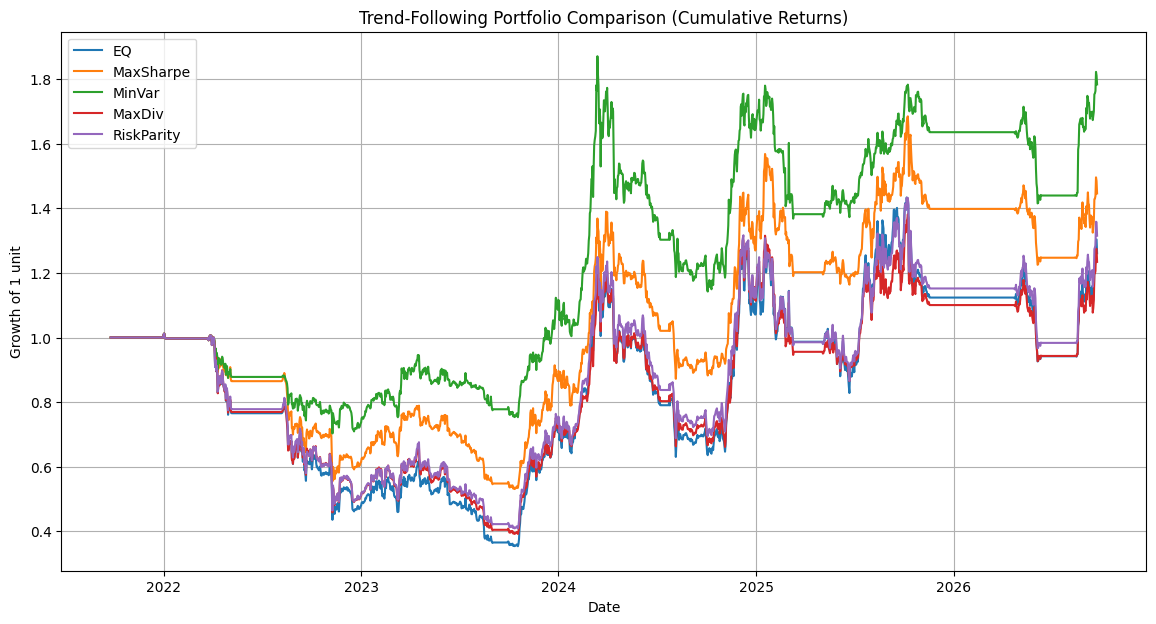


================ PORTFOLIO PERFORMANCE METRICS ================

+------------+--------------+-----------+--------+---------+----------+--------+----------+----------+-----------+------------+-------------+------------+------------+
| Strategy   | Ann Return % | Ann Vol % | Sharpe | Sortino | Max DD % | Calmar | Skewness | Kurtosis | VaR 95% % | CVaR 95% % | Hit Ratio % | Avg Gain % | Avg Loss % |
+============+==============+===========+========+=========+==========+========+==========+==========+===========+============+=============+============+============+
| EQ         | 9.986        | 36.763    | 0.272  | 0.419   | -65.040  | 0.154  | -0.156   | 7.458    | -3.520    | -5.846     | 35.014      | 1.958      | -1.923     |
| MaxSharpe  | 8.673        | 26.743    | 0.324  | 0.508   | -47.550  | 0.182  | -0.065   | 7.612    | -2.549    | -4.135     | 34.685      | 1.414      | -1.345     |
| MinVar     | 10.678       | 23.210    | 0.460  | 0.732   | -38.941  | 0.274  | 0.259    | 11

/tmp/ipykernel_3467/3990439110.py:99: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  out = out.applymap(_clean_cell)


In [7]:
######################## Portfolio Comparison & Visualization ##################

def compute_portfolio_metrics(port_ret, freq="daily"):
    """
    Compute a set of performance and risk metrics for a portfolio return series.
    """
    r = port_ret.dropna()

    if len(r) == 0:
        return {
            "Ann Return %": np.nan,
            "Ann Vol %": np.nan,
            "Sharpe": np.nan,
            "Sortino": np.nan,
            "Max DD %": np.nan,
            "Calmar": np.nan,
            "Skewness": np.nan,
            "Kurtosis": np.nan,
            "VaR 95% %": np.nan,
            "CVaR 95% %": np.nan,
            "Hit Ratio %": np.nan,
            "Avg Gain %": np.nan,
            "Avg Loss %": np.nan,
        }

    if freq == "daily":
        ann = 252
    elif freq == "hourly":
        ann = 252 * 24
    else:
        ann = 52

    mean_period = r.mean()
    vol_period = r.std()

    ann_return = mean_period * ann
    ann_vol = vol_period * np.sqrt(ann)

    sharpe = ann_return / ann_vol if ann_vol != 0 else np.nan

    downside = r.copy()
    downside[downside > 0] = 0
    downside_vol = downside.std() * np.sqrt(ann)
    sortino = ann_return / downside_vol if downside_vol != 0 else np.nan

    cum = (1 + r).cumprod()
    running_max = cum.cummax()
    drawdown = (cum - running_max) / running_max
    max_dd = drawdown.min()

    calmar = ann_return / abs(max_dd) if max_dd < 0 else np.nan

    skew = r.skew()
    kurt = r.kurt()

    var_95 = r.quantile(0.05)
    cvar_95 = r[r <= var_95].mean()

    hit_ratio = (r > 0).mean()
    avg_gain = r[r > 0].mean() if (r > 0).any() else np.nan
    avg_loss = r[r < 0].mean() if (r < 0).any() else np.nan

    return {
        "Ann Return %": ann_return * 100,
        "Ann Vol %": ann_vol * 100,
        "Sharpe": sharpe,
        "Sortino": sortino,
        "Max DD %": max_dd * 100,
        "Calmar": calmar,
        "Skewness": skew,
        "Kurtosis": kurt,
        "VaR 95% %": var_95 * 100,
        "CVaR 95% %": cvar_95 * 100,
        "Hit Ratio %": hit_ratio * 100,
        "Avg Gain %": avg_gain * 100,
        "Avg Loss %": avg_loss * 100,
    }


def _print_ascii_table(df: pd.DataFrame, title: str | None = None, max_col_width: int = 24):
    if df is None or df.empty:
        print("(empty table)")
        return

    out = df.copy()

    for c in out.columns:
        if pd.api.types.is_numeric_dtype(out[c]):
            out[c] = out[c].map(lambda x: "" if pd.isna(x) else f"{x:.3f}")

    out = out.astype(str)

    def _clean_cell(s: str) -> str:
        s = s.replace("\n", " ").replace("\r", " ").strip()
        if len(s) > max_col_width:
            s = s[: max_col_width - 1] + "…"
        return s

    out = out.applymap(_clean_cell)

    headers = [str(c) for c in out.columns]
    rows = out.values.tolist()

    widths = []
    for j, h in enumerate(headers):
        max_len = len(h)
        for r in rows:
            max_len = max(max_len, len(r[j]))
        widths.append(max_len)

    def _line(char: str = "-") -> str:
        return "+" + "+".join([char * (w + 2) for w in widths]) + "+"

    def _row(vals) -> str:
        return "|" + "|".join([f" {v:<{w}} " for v, w in zip(vals, widths)]) + "|"

    if title:
        print(title)

    print(_line("-"))
    print(_row(headers))
    print(_line("="))
    for r in rows:
        print(_row(r))
    print(_line("-"))


# ==================== TREND SIGNALS + BACKTESTS ====================

exchange = globals().get("exchange", "YahooFinance")
freq = globals().get("freq", "daily")

combined_path = Path("data") / exchange / f"{freq}_close.csv"

if not combined_path.exists():
    raise FileNotFoundError(f"Combined file not found: {combined_path}")

df_prices = pd.read_csv(combined_path)
df_prices.columns = df_prices.columns.str.lower()

df_prices["date"] = pd.to_datetime(df_prices["date"], errors="coerce")
df_prices = df_prices.dropna(subset=["date"])
df_prices.set_index("date", inplace=True)
df_prices.sort_index(inplace=True)

data = df_prices.copy()
ret = data.pct_change().dropna()

signals = compute_trend_signals(data, short_window=20, long_window=100)

transaction_fee = 0.001
estimation_window = 90
min_history = 30
max_weight = 0.33

net_eq, w_eq, _, _ = backtest_trend_equal_weight(ret, signals, transaction_fee, estimation_window, min_history, max_weight)
net_ms, w_ms, _, _ = backtest_trend_max_sharpe(ret, signals, transaction_fee, estimation_window, min_history, max_weight)
net_mv, w_mv, _, _ = backtest_trend_min_var(ret, signals, transaction_fee, estimation_window, min_history, max_weight)
net_md, w_md, _, _ = backtest_trend_max_diversification(ret, signals, transaction_fee, estimation_window, min_history, max_weight)
net_rp, w_rp, _, _ = backtest_trend_risk_parity(ret, signals, transaction_fee, estimation_window, min_history, max_weight)

strategies = {
    "EQ": net_eq,
    "MaxSharpe": net_ms,
    "MinVar": net_mv,
    "MaxDiv": net_md,
    "RiskParity": net_rp,
}

plt.figure(figsize=(14, 7))
for name, s in strategies.items():
    plt.plot((1 + s.dropna()).cumprod(), label=name)
plt.title("Trend-Following Portfolio Comparison (Cumulative Returns)")
plt.xlabel("Date")
plt.ylabel("Growth of 1 unit")
plt.legend()
plt.grid(True)
plt.show()

metrics = []
for name, s in strategies.items():
    m = compute_portfolio_metrics(s, freq=freq)
    m["Strategy"] = name
    metrics.append(m)

metrics_df = pd.DataFrame(metrics).set_index("Strategy")

print("\n================ PORTFOLIO PERFORMANCE METRICS ================\n")
_print_ascii_table(metrics_df.reset_index())

out_path = Path("data") / exchange / "TF_portfolio_metrics.csv"
out_path.parent.mkdir(parents=True, exist_ok=True)
metrics_df.to_csv(out_path)
print(f"\nSaved portfolio metrics to {out_path}")


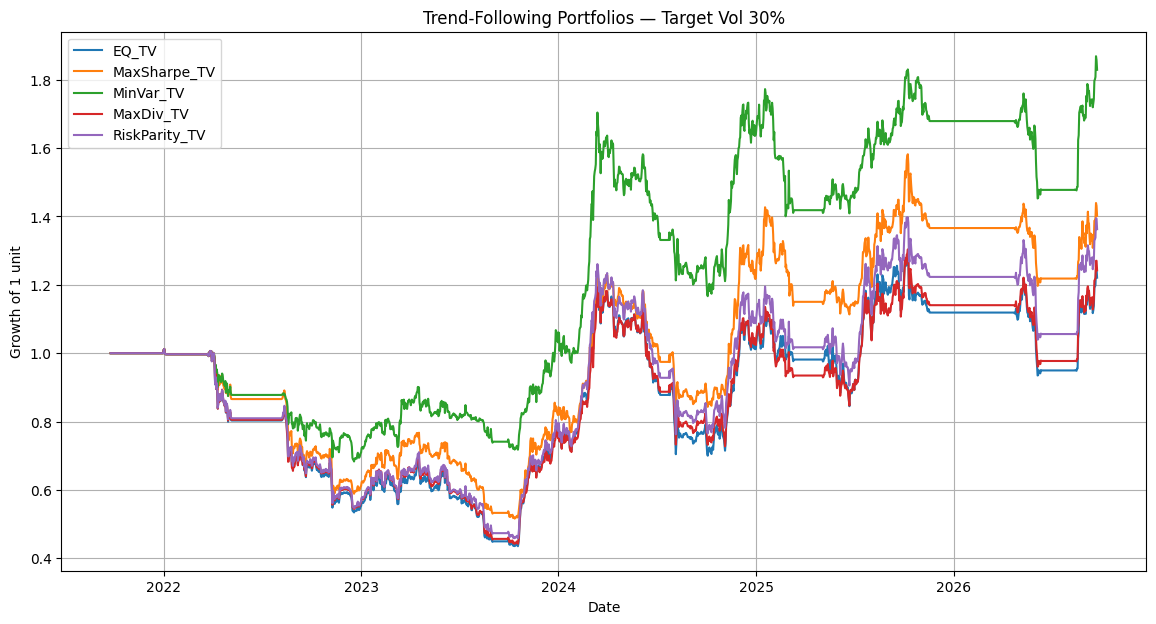


ORIGINAL STRATEGIES

Ann Return % Ann Vol % Sharpe Sortino Max DD % Calmar Skewness Kurtosis VaR 95% % CVaR 95% % Hit Ratio % Avg Gain % Avg Loss %   Strategy
       9.986    36.763  0.272   0.419  -65.040  0.154   -0.156    7.458    -3.520     -5.846      35.014      1.958     -1.923         EQ
       8.673    26.743  0.324   0.508  -47.550  0.182   -0.065    7.612    -2.549     -4.135      34.685      1.414     -1.345  MaxSharpe
      10.678    23.210  0.460   0.732  -38.941  0.274    0.259   11.460    -2.081     -3.511      35.452      1.190     -1.145     MinVar
       8.888    34.530  0.257   0.396  -61.279  0.145   -0.130    9.014    -3.267     -5.519      35.123      1.789     -1.772     MaxDiv
       9.689    34.311  0.282   0.436  -59.600  0.163   -0.128    8.184    -3.258     -5.443      35.452      1.801     -1.810 RiskParity

TARGET VOL STRATEGIES

Ann Return % Ann Vol % Sharpe Sortino Max DD % Calmar Skewness Kurtosis VaR 95% % CVaR 95% % Hit Ratio % Avg Gain % Avg Loss %

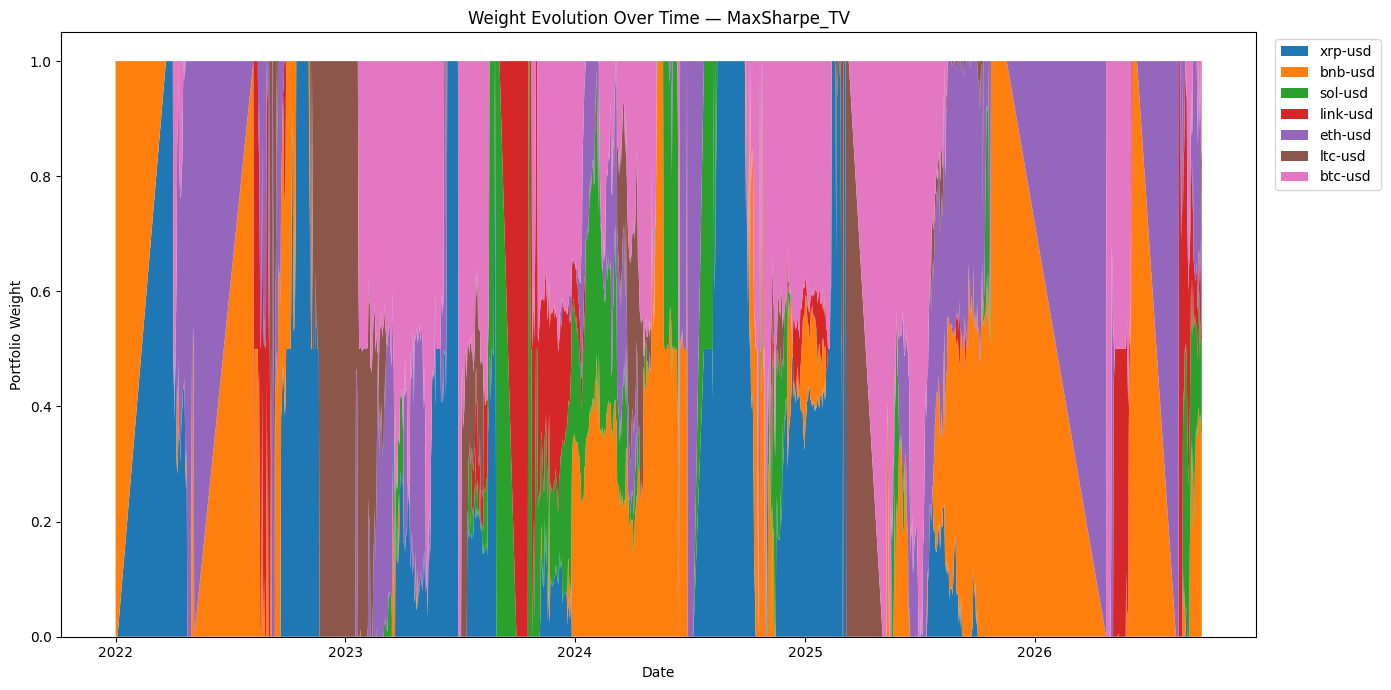

In [8]:
######################## Target Volatility Overlay & Full Comparison ##################

def apply_target_volatility(
    port_ret,
    target_vol_annual=0.30,
    vol_window=30,
    freq="daily",
    max_leverage=1.0,
    name_suffix="_TV"
):
    r = port_ret.dropna().copy()

    if len(r) < vol_window:
        adj_ret = r.copy()
        adj_ret.name = (port_ret.name or "strategy") + name_suffix
        scaling = pd.Series(1.0, index=r.index)
        return adj_ret, scaling

    if freq == "daily":
        ann = 252
    elif freq == "hourly":
        ann = 252 * 24
    else:
        ann = 52

    realized_vol = r.rolling(vol_window).std() * np.sqrt(ann)
    scaling = (target_vol_annual / realized_vol).clip(upper=max_leverage)
    scaling = scaling.replace([np.inf, -np.inf], np.nan).fillna(1.0)

    adj_ret = r * scaling
    adj_ret.name = (port_ret.name or "strategy") + name_suffix

    return adj_ret, scaling


def _print_matrix_table(df, float_digits=3):
    out = df.copy()
    for c in out.columns:
        if pd.api.types.is_numeric_dtype(out[c]):
            out[c] = out[c].map(lambda x: "" if pd.isna(x) else f"{x:.{float_digits}f}")
    print(out.to_string(index=False))


exchange = globals().get("exchange", "YahooFinance")
freq = globals().get("freq", "daily")

target_vol = 0.30
vol_window = 30

strategies_tv = {}
scalings_tv = {}

for name, s in strategies.items():
    adj, scale = apply_target_volatility(
        s,
        target_vol_annual=target_vol,
        vol_window=vol_window,
        freq=freq,
        max_leverage=1.0,
        name_suffix="_TV"
    )
    strategies_tv[name + "_TV"] = adj
    scalings_tv[name] = scale


# ===================== CUMULATIVE RETURNS =====================
plt.figure(figsize=(14, 7))
for name, s in strategies_tv.items():
    cum = (1 + s.dropna()).cumprod()
    plt.plot(cum.index, cum.values, label=name)
plt.title(f"Trend-Following Portfolios — Target Vol {int(target_vol*100)}%")
plt.xlabel("Date")
plt.ylabel("Growth of 1 unit")
plt.legend()
plt.grid(True)
plt.show()


# ===================== METRICS TABLES =====================
metrics_orig = []
for name, s in strategies.items():
    m = compute_portfolio_metrics(s, freq=freq)
    m["Strategy"] = name
    metrics_orig.append(m)

metrics_tv = []
for name, s in strategies_tv.items():
    m = compute_portfolio_metrics(s, freq=freq)
    m["Strategy"] = name
    metrics_tv.append(m)

metrics_orig_df = pd.DataFrame(metrics_orig)
metrics_tv_df = pd.DataFrame(metrics_tv)

print("\nORIGINAL STRATEGIES\n")
_print_matrix_table(metrics_orig_df)

print("\nTARGET VOL STRATEGIES\n")
_print_matrix_table(metrics_tv_df)


# ===================== WEIGHTS EVOLUTION — MAXSHARPE_TV =====================
if "MaxSharpe" in strategies and "MaxSharpe" in scalings_tv:

    w_base = w_ms.copy()
    scale = scalings_tv["MaxSharpe"]

    w_tv = w_base.mul(scale, axis=0)
    w_tv = w_tv.div(w_tv.sum(axis=1), axis=0)
    w_tv = w_tv.dropna()

    plt.figure(figsize=(14, 7))
    plt.stackplot(
        w_tv.index,
        [w_tv[c].values for c in w_tv.columns],
        labels=w_tv.columns
    )
    plt.title("Weight Evolution Over Time — MaxSharpe_TV")
    plt.xlabel("Date")
    plt.ylabel("Portfolio Weight")
    plt.legend(loc="upper left", bbox_to_anchor=(1.01, 1.0))
    plt.tight_layout()
    plt.show()


/tmp/ipykernel_3467/370978764.py:68: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=start_date, end=end_date, progress=False)
/tmp/ipykernel_3467/370978764.py:68: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=start_date, end=end_date, progress=False)


/tmp/ipykernel_3467/370978764.py:68: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=start_date, end=end_date, progress=False)


/tmp/ipykernel_3467/370978764.py:68: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=start_date, end=end_date, progress=False)
/tmp/ipykernel_3467/370978764.py:83: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  sp500_ret = benchmark_prices["SP500"]["SP500"].pct_change().dropna()
/tmp/ipykernel_3467/370978764.py:87: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  nasdaq_ret = benchmark_prices["NASDAQ"]["NASDAQ"].pct_change().dropna()


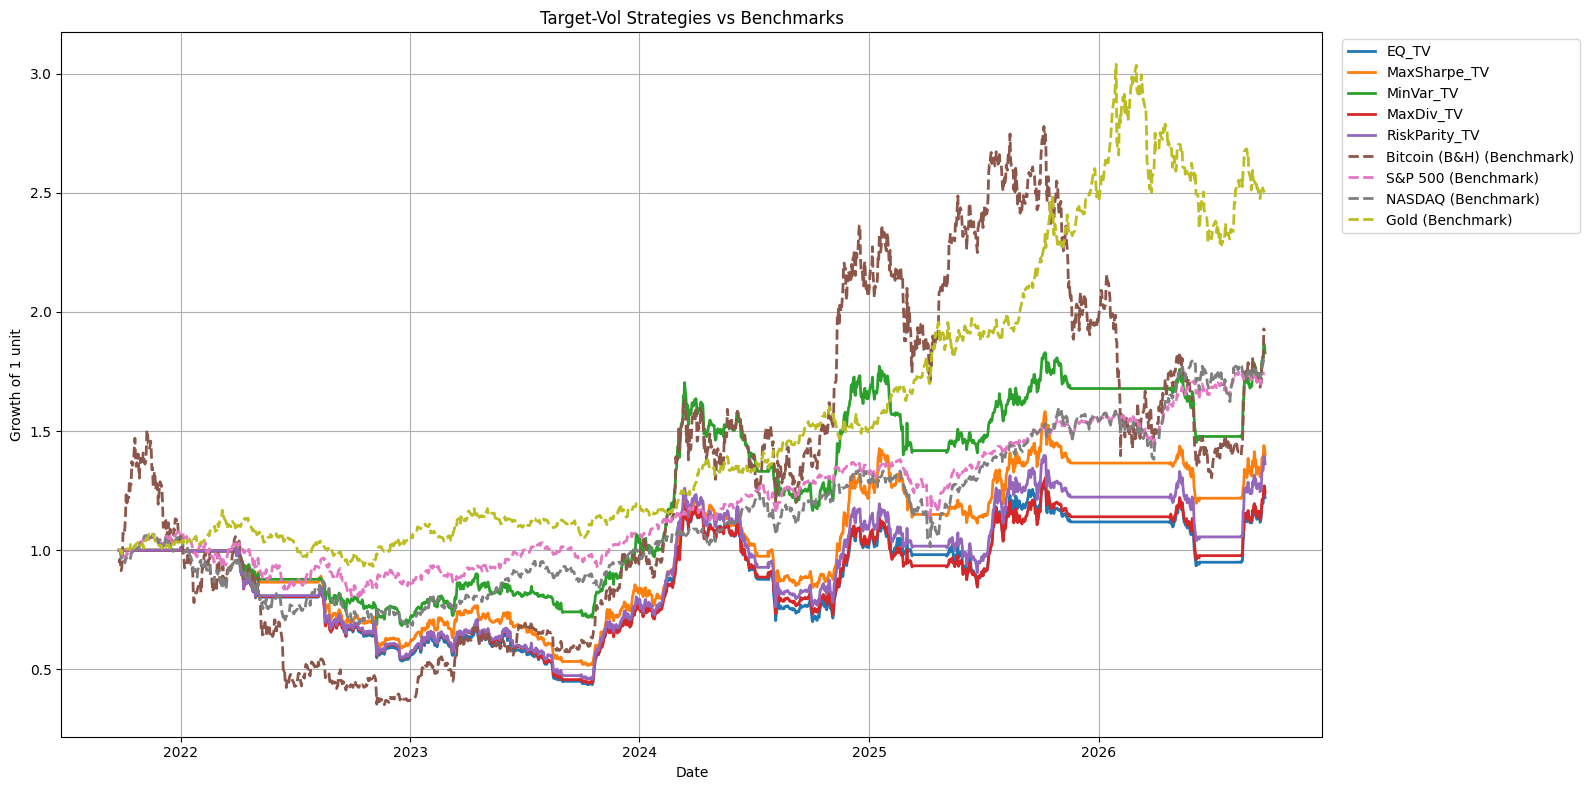


================ BENCHMARK PERFORMANCE METRICS ================

┌───────────────┬──────────────┬───────────┬────────┬─────────┬──────────┬────────┬──────────┬──────────┬───────────┬────────────┬─────────────┬────────────┬────────────┐
│ Benchmark     │ Ann Return % │ Ann Vol % │ Sharpe │ Sortino │ Max DD % │ Calmar │ Skewness │ Kurtosis │ VaR 95% % │ CVaR 95% % │ Hit Ratio % │ Avg Gain % │ Avg Loss % │
├───────────────┼──────────────┼───────────┼────────┼─────────┼──────────┼────────┼──────────┼──────────┼───────────┼────────────┼─────────────┼────────────┼────────────┤
│ Bitcoin (B&H) │ 18.179       │ 42.849    │ 0.424  │ 0.713   │ -76.635  │ 0.237  │ 0.102    │ 4.076    │ -4.030    │ -6.136     │ 49.479      │ 1.948      │ -1.765     │
│ S&P 500       │ 12.651       │ 17.036    │ 0.743  │ 1.222   │ -25.425  │ 0.498  │ 0.162    │ 6.950    │ -1.643    │ -2.456     │ 53.312      │ 0.765      │ -0.768     │
│ NASDAQ        │ 14.448       │ 22.845    │ 0.632  │ 1.050   │ -36.395  │ 0.39

/tmp/ipykernel_3467/370978764.py:29: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  out = out.applymap(_clean_cell)


In [9]:
######################## BENCHMARK COMPARISON  ########################

benchmark_tickers = {
    "BTC_BH": "BTC-USD",
    "SP500": "^GSPC",
    "NASDAQ": "^IXIC",
    "GOLD": "GC=F"
}

def _print_matrix_table(df: pd.DataFrame, title: str | None = None, float_digits: int = 3, max_col_width: int = 24):
    if df is None or df.empty:
        print("(empty table)")
        return

    out = df.copy()

    for c in out.columns:
        if pd.api.types.is_numeric_dtype(out[c]):
            out[c] = out[c].map(lambda x: "" if pd.isna(x) else f"{x:.{float_digits}f}")

    out = out.astype(str)

    def _clean_cell(s: str) -> str:
        s = s.replace("\n", " ").replace("\r", " ").strip()
        if len(s) > max_col_width:
            s = s[: max_col_width - 1] + "…"
        return s

    out = out.applymap(_clean_cell)

    headers = [str(c) for c in out.columns]
    rows = out.values.tolist()

    widths = []
    for j, h in enumerate(headers):
        m = len(h)
        for r in rows:
            m = max(m, len(r[j]))
        widths.append(m)

    def _cell(v: str, w: int) -> str:
        return f" {v:<{w}} "

    def _hline(left: str, mid: str, right: str, fill: str = "─") -> str:
        parts = [fill * (w + 2) for w in widths]
        return left + mid.join(parts) + right

    def _row(vals) -> str:
        return "│" + "│".join([_cell(v, w) for v, w in zip(vals, widths)]) + "│"

    if title:
        print(title)

    print(_hline("┌", "┬", "┐", "─"))
    print(_row(headers))
    print(_hline("├", "┼", "┤", "─"))
    for r in rows:
        print(_row(r))
    print(_hline("└", "┴", "┘", "─"))


benchmark_prices = {}
start_date = data.index.min().strftime("%Y-%m-%d")
end_date = data.index.max().strftime("%Y-%m-%d")

for name, ticker in benchmark_tickers.items():
    print(f"Downloading benchmark: {name} ({ticker})")
    df = yf.download(ticker, start=start_date, end=end_date, progress=False)
    if df.empty:
        print(f"WARNING: No data for {name}. Skipping.")
        continue
    df = df[["Close"]].rename(columns={"Close": name})
    df.index = pd.to_datetime(df.index)
    benchmark_prices[name] = df

bench_series_list = []

if "BTC_BH" in benchmark_prices:
    btc_ret = benchmark_prices["BTC_BH"]["BTC_BH"].pct_change().dropna()
    bench_series_list.append(btc_ret)

if "SP500" in benchmark_prices:
    sp500_ret = benchmark_prices["SP500"]["SP500"].pct_change().dropna()
    bench_series_list.append(sp500_ret)

if "NASDAQ" in benchmark_prices:
    nasdaq_ret = benchmark_prices["NASDAQ"]["NASDAQ"].pct_change().dropna()
    bench_series_list.append(nasdaq_ret)

if "GOLD" in benchmark_prices:
    gold_ret = benchmark_prices["GOLD"]["GOLD"].pct_change().dropna()
    bench_series_list.append(gold_ret)

bench_returns = pd.concat(bench_series_list, axis=1) if len(bench_series_list) > 0 else pd.DataFrame()

tv_strategies_df = pd.DataFrame(strategies_tv)

plt.figure(figsize=(16, 8))

for col in tv_strategies_df.columns:
    r = tv_strategies_df[col].dropna()
    cum = (1 + r).cumprod()
    plt.plot(cum.index, cum.values, label=col, linewidth=2)

pretty_labels = {
    "BTC_BH": "Bitcoin (B&H)",
    "BTC-USD": "Bitcoin (B&H)",
    "^GSPC": "S&P 500",
    "GSPC": "S&P 500",
    "SP500": "S&P 500",
    "^IXIC": "NASDAQ",
    "IXIC": "NASDAQ",
    "NASDAQ": "NASDAQ",
    "GC=F": "Gold",
    "GOLD": "Gold",
}

for col in bench_returns.columns:
    r = bench_returns[col].dropna()
    cum = (1 + r).cumprod()
    label_clean = pretty_labels.get(col, col)

    plt.plot(
        cum.index,
        cum.values,
        linestyle="--",
        linewidth=2,
        label=f"{label_clean} (Benchmark)"
    )

plt.title("Target-Vol Strategies vs Benchmarks")
plt.xlabel("Date")
plt.ylabel("Growth of 1 unit")
plt.legend(loc="upper left", bbox_to_anchor=(1.01, 1))
plt.grid(True)
plt.tight_layout()
plt.show()

freq = globals().get("freq", "daily")

benchmark_metrics_list = []
for col in bench_returns.columns:
    m = compute_portfolio_metrics(bench_returns[col].dropna(), freq=freq)
    m["Benchmark"] = pretty_labels.get(col, col)
    benchmark_metrics_list.append(m)

bench_metrics_df = pd.DataFrame(benchmark_metrics_list).set_index("Benchmark") if len(benchmark_metrics_list) > 0 else pd.DataFrame()

if not bench_metrics_df.empty:
    bench_metrics_df = bench_metrics_df[[
        "Ann Return %",
        "Ann Vol %",
        "Sharpe",
        "Sortino",
        "Max DD %",
        "Calmar",
        "Skewness",
        "Kurtosis",
        "VaR 95% %",
        "CVaR 95% %",
        "Hit Ratio %",
        "Avg Gain %",
        "Avg Loss %",
    ]]

    print("\n================ BENCHMARK PERFORMANCE METRICS ================\n")
    _print_matrix_table(bench_metrics_df.reset_index(), title=None, float_digits=3, max_col_width=24)
else:
    print("\nNo benchmark metrics available (no benchmark return series).")


Running macro correlation analysis for MaxSharpe_TV...


/tmp/ipykernel_3467/2588430683.py:75: FutureWarning: YF.download() has changed argument auto_adjust default to True
  macro_prices = yf.download(
/tmp/ipykernel_3467/2588430683.py:87: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  macro_returns = macro_prices.pct_change().dropna()
/tmp/ipykernel_3467/2588430683.py:101: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  gdp = gdp.resample("Q").last()


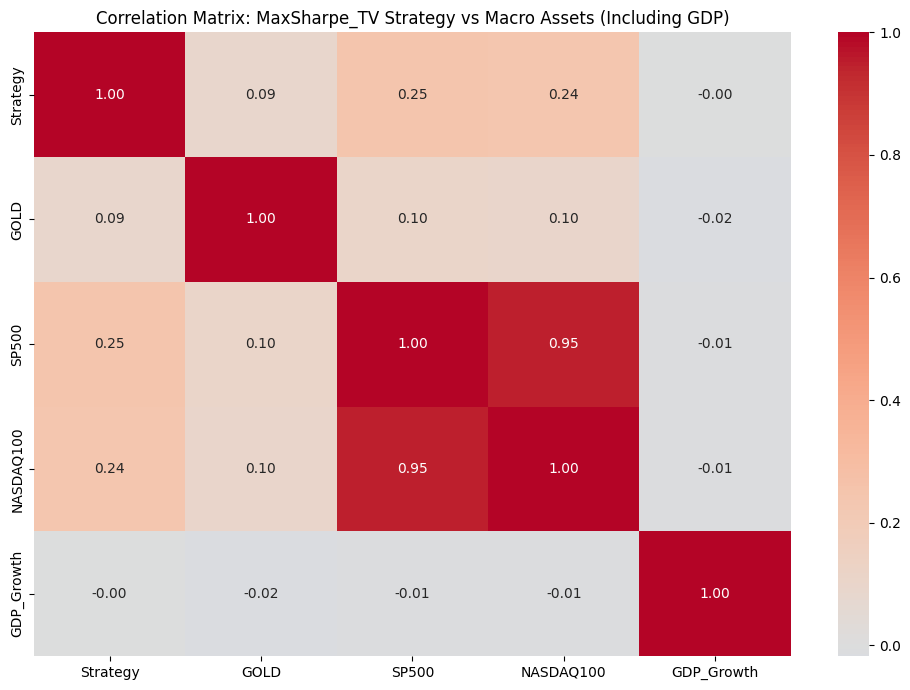

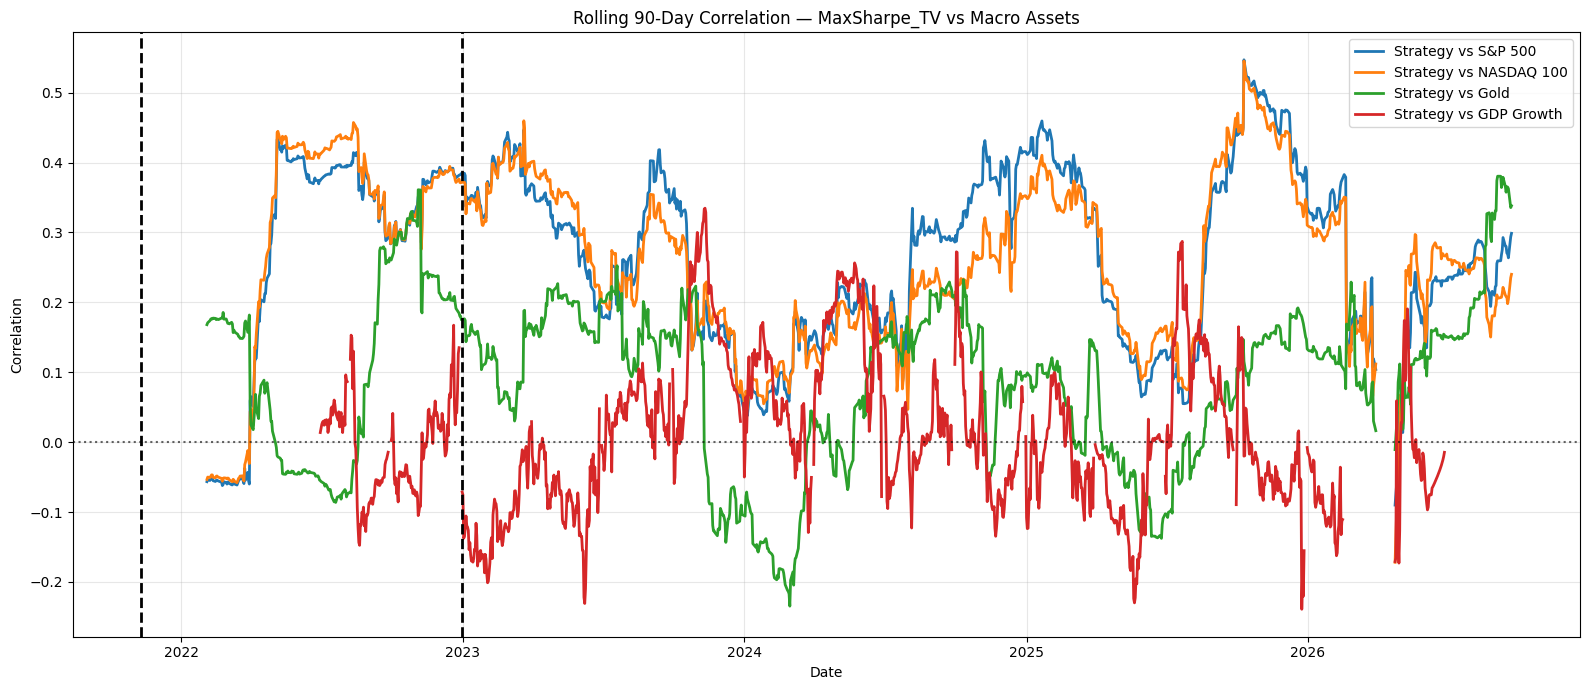


================ MEAN ROLLING CORRELATION BY CRYPTO REGIME (MaxSharpe_TV) ================

┌───────────────┬─────────┬────────────┬───────┐
│ Regime        │ S&P 500 │ NASDAQ 100 │ Gold  │
├───────────────┼─────────┼────────────┼───────┤
│ FULL_SAMPLE   │ 0.268   │ 0.261      │ 0.090 │
│ CRYPTO_BULL   │         │            │       │
│ CRYPTO_WINTER │ 0.280   │ 0.293      │ 0.108 │
│ POST_WINTER   │ 0.265   │ 0.253      │ 0.085 │
└───────────────┴─────────┴────────────┴───────┘


/tmp/ipykernel_3467/2588430683.py:26: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  out = out.applymap(_clean_cell)


In [10]:
#############################################
# MACRO CORRELATION + CRYPTO REGIMES (MaxSharpe_TV)
#############################################

import pandas_datareader.data as web

def _print_matrix_table(df: pd.DataFrame, title: str | None = None, float_digits: int = 3, max_col_width: int = 24):
    if df is None or df.empty:
        print("(empty table)")
        return

    out = df.copy()

    for c in out.columns:
        if pd.api.types.is_numeric_dtype(out[c]):
            out[c] = out[c].map(lambda x: "" if pd.isna(x) else f"{x:.{float_digits}f}")

    out = out.astype(str)

    def _clean_cell(s: str) -> str:
        s = s.replace("\n", " ").replace("\r", " ").strip()
        if len(s) > max_col_width:
            s = s[: max_col_width - 1] + "…"
        return s

    out = out.applymap(_clean_cell)

    headers = [str(c) for c in out.columns]
    rows = out.values.tolist()

    widths = []
    for j, h in enumerate(headers):
        m = len(h)
        for r in rows:
            m = max(m, len(r[j]))
        widths.append(m)

    def _cell(v: str, w: int) -> str:
        return f" {v:<{w}} "

    def _hline(left: str, mid: str, right: str, fill: str = "─") -> str:
        parts = [fill * (w + 2) for w in widths]
        return left + mid.join(parts) + right

    def _row(vals) -> str:
        return "│" + "│".join([_cell(v, w) for v, w in zip(vals, widths)]) + "│"

    if title:
        print(title)

    print(_hline("┌", "┬", "┐", "─"))
    print(_row(headers))
    print(_hline("├", "┼", "┤", "─"))
    for r in rows:
        print(_row(r))
    print(_hline("└", "┴", "┘", "─"))


print("Running macro correlation analysis for MaxSharpe_TV...")

if "strategies_tv" not in globals():
    raise NameError("strategies_tv not found.")
if "ret" not in globals():
    raise NameError("ret not found.")
if "MaxSharpe_TV" not in strategies_tv:
    raise KeyError("MaxSharpe_TV not found in strategies_tv.")

strategy = strategies_tv["MaxSharpe_TV"].copy()
strategy.index = pd.to_datetime(strategy.index)
strategy = strategy.resample("1D").mean().dropna()
strategy.name = "Strategy"

macro_tickers = ["^GSPC", "^NDX", "GC=F"]

macro_prices = yf.download(
    macro_tickers,
    start=strategy.index.min(),
    end=strategy.index.max(),
    interval="1d",
    progress=False
)

if macro_prices.empty:
    raise ValueError("No macro price data downloaded.")

macro_prices = macro_prices["Close"]
macro_returns = macro_prices.pct_change().dropna()
macro_returns.index = pd.to_datetime(macro_returns.index)

macro_rename = {"^GSPC": "SP500", "^NDX": "NASDAQ100", "GC=F": "GOLD"}
macro_returns = macro_returns.rename(columns=macro_rename)

try:
    gdp = web.DataReader("GDP", "fred", start=strategy.index.min(), end=strategy.index.max())
except Exception as e:
    raise RuntimeError(f"Error downloading GDP from FRED: {e}")

if gdp.empty:
    raise ValueError("GDP series is empty.")

gdp = gdp.resample("Q").last()
gdp_returns = gdp.pct_change().dropna()
gdp_returns.rename(columns={"GDP": "GDP_Growth"}, inplace=True)
gdp_daily = gdp_returns.resample("1D").ffill()

combined_all = pd.concat([strategy, macro_returns, gdp_daily], axis=1)

corr_all = combined_all.corr()

plt.figure(figsize=(10, 7))
sns.heatmap(corr_all, annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("Correlation Matrix: MaxSharpe_TV Strategy vs Macro Assets (Including GDP)")
plt.tight_layout()
plt.show()

window = 90

combined_fin = pd.concat([strategy, macro_returns], axis=1).dropna()
combined_gdp_only = pd.concat([strategy, gdp_daily], axis=1).dropna()

roll_sp = combined_fin["Strategy"].rolling(window).corr(combined_fin["SP500"])
roll_ndx = combined_fin["Strategy"].rolling(window).corr(combined_fin["NASDAQ100"])
roll_gold = combined_fin["Strategy"].rolling(window).corr(combined_fin["GOLD"])
roll_gdp = combined_gdp_only["Strategy"].rolling(window).corr(combined_gdp_only["GDP_Growth"])

regime_1_start = pd.to_datetime("2017-01-01")
regime_1_end = pd.to_datetime("2021-11-10")
regime_2_start = pd.to_datetime("2021-11-11")
regime_2_end = pd.to_datetime("2022-12-31")
regime_3_start = pd.to_datetime("2023-01-01")
regime_3_end = pd.to_datetime(max(roll_sp.dropna().index.max(), roll_gold.dropna().index.max()))

plt.figure(figsize=(16, 7))
plt.plot(roll_sp, label="Strategy vs S&P 500", linewidth=2)
plt.plot(roll_ndx, label="Strategy vs NASDAQ 100", linewidth=2)
plt.plot(roll_gold, label="Strategy vs Gold", linewidth=2)
plt.plot(roll_gdp, label="Strategy vs GDP Growth", linewidth=2)

plt.axvline(regime_1_end, color="black", linestyle="--", linewidth=2)
plt.axvline(regime_2_end, color="black", linestyle="--", linewidth=2)
plt.axhline(0, color="black", linestyle=":", alpha=0.6)

plt.title("Rolling 90-Day Correlation — MaxSharpe_TV vs Macro Assets")
plt.xlabel("Date")
plt.ylabel("Correlation")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

def _mean_corr(series: pd.Series, start: pd.Timestamp, end: pd.Timestamp) -> float:
    sub = series.loc[(series.index >= start) & (series.index <= end)].dropna()
    return float(sub.mean()) if len(sub) else np.nan

regimes = {
    "FULL_SAMPLE": (pd.to_datetime("1900-01-01"), pd.to_datetime("2100-01-01")),
    "CRYPTO_BULL": (regime_1_start, regime_1_end),
    "CRYPTO_WINTER": (regime_2_start, regime_2_end),
    "POST_WINTER": (regime_3_start, regime_3_end),
}

corr_table = pd.DataFrame(
    index=list(regimes.keys()),
    columns=["S&P 500", "NASDAQ 100", "Gold"],
    dtype=float
)

for reg_name, (start, end) in regimes.items():
    corr_table.loc[reg_name, "S&P 500"] = _mean_corr(roll_sp, start, end)
    corr_table.loc[reg_name, "NASDAQ 100"] = _mean_corr(roll_ndx, start, end)
    corr_table.loc[reg_name, "Gold"] = _mean_corr(roll_gold, start, end)

print("\n================ MEAN ROLLING CORRELATION BY CRYPTO REGIME (MaxSharpe_TV) ================\n")
_print_matrix_table(corr_table.reset_index().rename(columns={"index": "Regime"}), title=None, float_digits=3, max_col_width=24)


Full sample start: 2021-09-25
Full sample end  : 2026-09-23
Split date (75% point): 2025-06-23
In-sample length : 1368 days ( 75.0 % )
Out-of-sample len: 457 days ( 25.0 % )

================ MAXSHARPE_TV — IN-SAMPLE vs OUT-OF-SAMPLE ================

┌───────────────┬──────────────┬───────────┬────────┬─────────┬──────────┬────────┬──────────┬──────────┬───────────┬────────────┬─────────────┬────────────┬────────────┐
│ Sample        │ Ann Return % │ Ann Vol % │ Sharpe │ Sortino │ Max DD % │ Calmar │ Skewness │ Kurtosis │ VaR 95% % │ CVaR 95% % │ Hit Ratio % │ Avg Gain % │ Avg Loss % │
├───────────────┼──────────────┼───────────┼────────┼─────────┼──────────┼────────┼──────────┼──────────┼───────────┼────────────┼─────────────┼────────────┼────────────┤
│ In-sample     │ 5.025        │ 23.114    │ 0.217  │ 0.340   │ -48.983  │ 0.103  │ -0.173   │ 5.257    │ -2.357    │ -3.619     │ 37.061      │ 1.205      │ -1.158     │
│ Out-of-sample │ 13.468       │ 19.387    │ 0.695  │ 1.140   │ 

/tmp/ipykernel_3467/2180949589.py:22: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  out = out.applymap(_clean_cell)


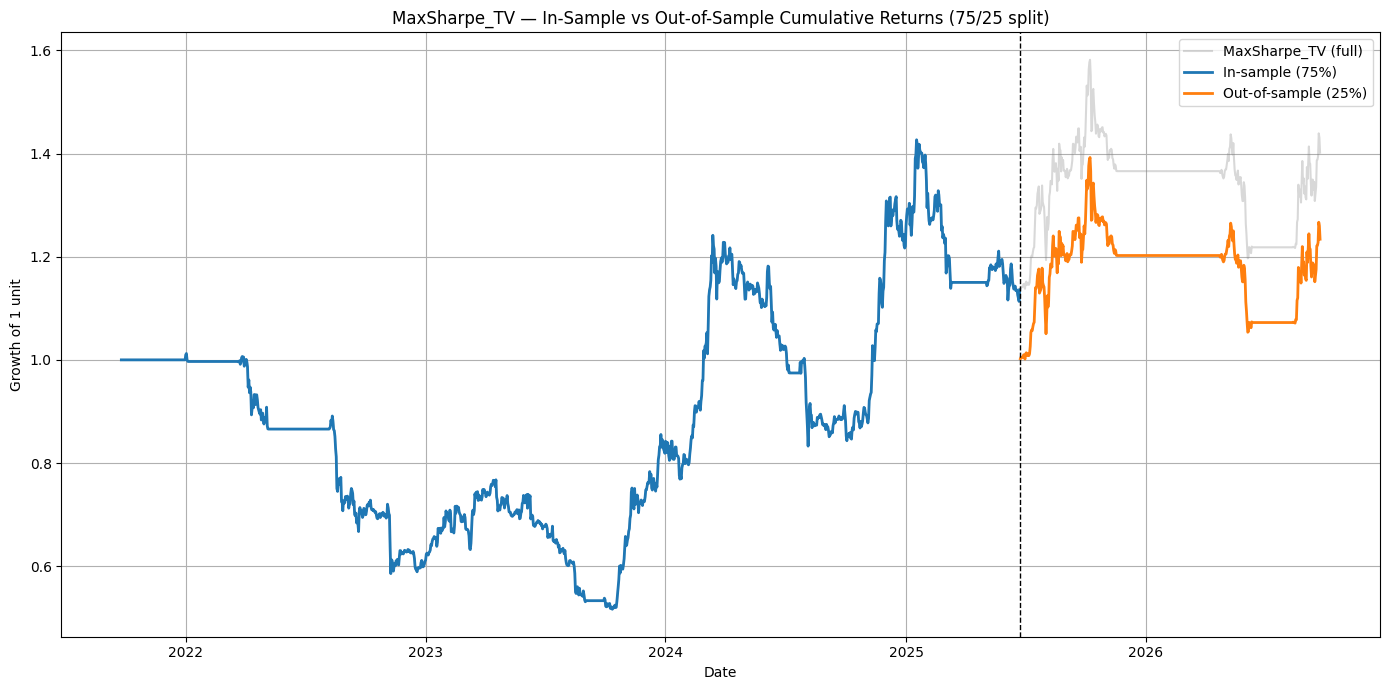

In [11]:
######################## In-Sample vs Out-of-Sample (MaxSharpe_TV) ########################

def _print_matrix_table(df: pd.DataFrame, title: str | None = None, float_digits: int = 3, max_col_width: int = 24):
    if df is None or df.empty:
        print("(empty table)")
        return

    out = df.copy()

    for c in out.columns:
        if pd.api.types.is_numeric_dtype(out[c]):
            out[c] = out[c].map(lambda x: "" if pd.isna(x) else f"{x:.{float_digits}f}")

    out = out.astype(str)

    def _clean_cell(s: str) -> str:
        s = s.replace("\n", " ").replace("\r", " ").strip()
        if len(s) > max_col_width:
            s = s[: max_col_width - 1] + "…"
        return s

    out = out.applymap(_clean_cell)

    headers = [str(c) for c in out.columns]
    rows = out.values.tolist()

    widths = []
    for j, h in enumerate(headers):
        m = len(h)
        for r in rows:
            m = max(m, len(r[j]))
        widths.append(m)

    def _cell(v: str, w: int) -> str:
        return f" {v:<{w}} "

    def _hline(left: str, mid: str, right: str, fill: str = "─") -> str:
        parts = [fill * (w + 2) for w in widths]
        return left + mid.join(parts) + right

    def _row(vals) -> str:
        return "│" + "│".join([_cell(v, w) for v, w in zip(vals, widths)]) + "│"

    if title:
        print(title)

    print(_hline("┌", "┬", "┐", "─"))
    print(_row(headers))
    print(_hline("├", "┼", "┤", "─"))
    for r in rows:
        print(_row(r))
    print(_hline("└", "┴", "┘", "─"))


if "strategies_tv" not in globals():
    raise NameError("strategies_tv not found.")
if "MaxSharpe_TV" not in strategies_tv:
    raise KeyError("MaxSharpe_TV not found in strategies_tv.")

freq = globals().get("freq", "daily")

maxsharpe_tv = strategies_tv["MaxSharpe_TV"].dropna().copy()
maxsharpe_tv.name = "MaxSharpe_TV"

n_obs = len(maxsharpe_tv)
split_idx = int(n_obs * 0.75)

if split_idx < 30:
    raise ValueError("Not enough data to perform a meaningful 75/25 IS–OOS split.")

is_ret = maxsharpe_tv.iloc[:split_idx]
oos_ret = maxsharpe_tv.iloc[split_idx:]

split_date = is_ret.index[-1]

print("Full sample start:", maxsharpe_tv.index.min().date())
print("Full sample end  :", maxsharpe_tv.index.max().date())
print("Split date (75% point):", split_date.date())
print("In-sample length :", len(is_ret), "days (", round(len(is_ret) / n_obs * 100, 1), "% )")
print("Out-of-sample len:", len(oos_ret), "days (", round(len(oos_ret) / n_obs * 100, 1), "% )")

is_metrics = compute_portfolio_metrics(is_ret, freq=freq)
oos_metrics = compute_portfolio_metrics(oos_ret, freq=freq)

is_metrics["Sample"] = "In-sample"
oos_metrics["Sample"] = "Out-of-sample"

metrics_io = pd.DataFrame([is_metrics, oos_metrics]).set_index("Sample")

metrics_io = metrics_io[[
    "Ann Return %",
    "Ann Vol %",
    "Sharpe",
    "Sortino",
    "Max DD %",
    "Calmar",
    "Skewness",
    "Kurtosis",
    "VaR 95% %",
    "CVaR 95% %",
    "Hit Ratio %",
    "Avg Gain %",
    "Avg Loss %",
]].round(3)

print("\n================ MAXSHARPE_TV — IN-SAMPLE vs OUT-OF-SAMPLE ================\n")
_print_matrix_table(metrics_io.reset_index(), title=None, float_digits=3, max_col_width=24)

cum_full = (1 + maxsharpe_tv).cumprod()
cum_is = (1 + is_ret).cumprod()
cum_oos = (1 + oos_ret).cumprod()

plt.figure(figsize=(14, 7))
plt.plot(cum_full.index, cum_full.values, label="MaxSharpe_TV (full)", color="gray", alpha=0.3)
plt.plot(cum_is.index, cum_is.values, label="In-sample (75%)", linewidth=2)
plt.plot(cum_oos.index, cum_oos.values, label="Out-of-sample (25%)", linewidth=2)

plt.axvline(split_date, color="black", linestyle="--", linewidth=1)
plt.title("MaxSharpe_TV — In-Sample vs Out-of-Sample Cumulative Returns (75/25 split)")
plt.xlabel("Date")
plt.ylabel("Growth of 1 unit")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
